In [1]:
import numpy as np
import pandas as pd
from functools import partial
from scipy.optimize import minimize

import matplotlib.pyplot as plt

# Advanced Applied Econometrics - Summer 2026

## Static discrete choice labor supply

### Model setup

**Random utility model**

Individuals $i$ choose to work $h_{ij} \in \{0, 10, 20, 30, 40\}$ hours per week, where $j$ indexes the discrete alternatives. Preferences are described by:

$$U_{ij} = \gamma~\left[\frac{c_{ij}^\theta}{\theta} - \alpha\, h_{ij}\right] + \varepsilon_{ij} \qquad \forall\, i,\, j$$

where $\varepsilon_{ij}$ are i.i.d. Type-I extreme value distributed preference shocks, $\theta$ is the curvature parameter of consumption utility (the coefficient of relative risk aversion is $1-\theta$), and $\alpha$ captures the disutility of working hours. The scale parameter $\gamma$ is **normalised to 1** throughout: since only the product $\gamma \alpha$ — and not $\gamma$ and $\alpha$ separately — affects choice probabilities, $\gamma$ is not separately identified from $\alpha$ in cross-sectional data and must be fixed for estimation.

---

**Budget constraint and wage equation**

$$c_{ij} = y_i + \omega_i \cdot h_{ij} - T(\omega_i \cdot h_{ij})$$

$$\log(\omega_i) = \mu_\omega + \varepsilon^\omega_i, \qquad \varepsilon^\omega_i \sim \mathcal{N}(0,\, \sigma_\omega^2)$$

where $y_i$ is non-labour income, $\omega_i$ is the gross hourly wage, and $T(\cdot)$ is the tax function:

$$T(E) = \begin{cases} 0 & \text{if } E \leq 80 \\ t \cdot (E - 80) & \text{if } E > 80 \end{cases}$$

with marginal tax rate $t = 0.3$ on weekly labour earnings $E = \omega_i \cdot h_{ij}$ above the threshold. Non-labour income is not taxed.

---

**Calibrated parameters for simulation**

| Parameter | Value |
|-----------|-------|
| Non-labour income | $y_i \sim \mathrm{Uniform}[10, 100]$ |
| Wage mean | $\mu_\omega = 1$ |
| Wage dispersion | $\sigma_\omega = 0.55$ |
| CRRA curvature | $\theta = 0.3$ |
| Utility scale | $\gamma = 1$ (normalised) |
| Hours disutility | $\alpha = 0.1$ |

## Problem 1: General questions

**1.1** Why is a discrete choice framework attractive for modelling labour supply? Discuss at least three arguments, drawing on (i) the empirical distribution of working hours, (ii) the structure of tax-transfer systems, and (iii) computational considerations.

#### (i) Empirical reality/institutional constraints
- Many jobs offer fixed hour contracts. Working hours typically cluster at specific values (part-time, full-time) which we can capture with distinct choice categories. The discrete set (e.g. {0,10,20,30,40}) approximates these mass points directly.
- The number of choice alternatives: detailed enough to capture observed behavioral choices, but less options generally improve computational tractability. 

#### (ii) Structure of the tax-transfer system
- The complex structure of the tax-transfer system can result in non-linearities and non-convexities of the budget sets which are hard to characterize appropriately and significantly complicating any continuous optimization procedure.
- Each DC alternative maps cleanly to a (h,c) bundle.

#### (iii) Computational tractability
- Given the distributional assumption on utility unobservables (Type-1 EV), we obtain closed form logit choice probabilities (circumventing specification of the joint distribution of utility errors and numerical integration)
- Corner solutions (non-participation) need no special treatment.

---
### Sketch - Notes on Discrete choice random utility models
**Random utility models (RUM)** describe the choice of individual $i$ from a finite set of alternatives $j = 1, \ldots, J$:

$$U_{ij} = x_{ij}'\beta + \varepsilon_{ij} \qquad \forall\; i=1,\ldots,N,\quad j=1,\ldots,J$$

$$\text{Pr}(y_i = j) = \text{Pr}(U_{ij} = \max\{U_{i1},\ldots,U_{iJ}\}) = \text{Pr}\!\left(x_{ij}'\beta + \varepsilon_{ij} > \max_{k \neq j}\{x_{ik}'\beta + \varepsilon_{ik}\}\right)$$

**Multinomial Probit (MNP):** assume unobservables are jointly normal, $\varepsilon_{ij} \sim N(0,\Sigma)$, where $\Sigma$ is a $J\times J$ covariance matrix.

$$\text{Pr}(y_i = j) = \text{Pr}\!\left(\varepsilon_{i1} - \varepsilon_{ij} < x_{ij}'\beta - x_{i1}'\beta,\;\forall\, k \neq j\right)$$

...given by the cumulative probability of a $(J-1)$-variate normal distribution. Estimation is computationally expensive, requiring numerical integration over the joint distribution of the unobservables.

**Multinomial Logit / Conditional Logit (MNL/CL):** assume unobservables are i.i.d. Type I extreme value (Gumbel) distributed (independent across individuals & alternatives):

$$\text{CDF}_{\text{EV-I}}(\varepsilon_{ij}) = e^{-e^{-\varepsilon_{ij}}} \qquad \forall\; i,j$$

Economic foundation by McFadden (1973): differences between errors in RUM follow the logit distribution. Maximisation of the stochastic utility function yields a closed-form solution for choice probabilities (Train, 2009, p. 85):

$$\text{Pr}(y_i = j) = \frac{e^{x_{ij}'\beta}}{\sum_{k=1}^J e^{x_{ik}'\beta}} \qquad \forall\; i,j$$

**Intuition for the closed form.** The convenience of EV-I errors rests on two closure properties: (i) the maximum of a set of i.i.d. EV-I shifted variables is itself EV-I, and (ii) the difference of two independent EV-I variables is logistic. Together these imply that the probability that alternative $j$ attains the maximum utility collapses to the exponential-share formula above, with no integration required and makes the logit tractable relative to the probit.

**1.2** The choice set used here is $\{0, 10, 20, 30, 40\}$ hours per week. What considerations should guide the specification of the choice set in practice? What are the potential costs of including too few or too many alternatives?

- Should reflect the empirical support of the hours distribution observed in the data, i.e. add alternative at observed spikes.
- Too coarse: misrepresents behavior, especially around specific decision margins (e.g. a kink in the tax/budget function)
- Too fine: approximates the continuous case and limits computational tractability

**Common practice**: inspect the data first and set alternative at observed mass points.
- E.g. consider differences in working hours for men and women in Germany. Since the majority of men work in full-time contracts, using only two or three hours alternatives might provide a sufficient approximation ({0,20,40}). In contrast, the large share of women working in different part-time arrangements might require a more granular specification.

**1.3** For an individual with non-labour income $y_i = 50$ and hourly wage $\omega_i = 6$, compute consumption $c_{ij}$ at each hours alternative and sketch the resulting budget set (consumption on the vertical axis, hours on the horizontal). At which point does the tax start to bind, and what does the kink look like?

In [2]:
def compute_consumption_by_hours_choice(
        hours_options, non_labor_income, hourly_wage, tax_threshold, tax_rate
):
    """ Calculate consumption at each hours choice option.
    Args:
        hours_options (np.array): 1d array of hours choice alternative
        non_labor_income (scalar)
        hourly_wage (scalar)
        tax_threshold (scalar): tax exemption threshold based on labor income
        tax_rate (scalar): marginal tax rate

    Returns:
        consumption (np.array): 1d array of consumption value for each hours choice option. Shape (num_hours_options,)
    """

    # Compute labor income
    labor_income = hourly_wage*hours_options

    # Specify tax function
    taxes = np.where(
        labor_income > tax_threshold,
        tax_rate * (labor_income - tax_threshold),
        0,
    )

    # Specify budget equation and compute consumption
    consumption = non_labor_income + hourly_wage*hours_options - taxes

    return consumption

In [3]:
# Define inputs:
non_labor_income = 50
hourly_wage = 6
hours_options = np.array([0, 10, 20, 30, 40])
tax_threshold = 80    # threshold from model setup: T(E) = 0.3*(E-80) for E>80
tax_rate = 0.3

# compute consumption
consump = compute_consumption_by_hours_choice(
    hours_options, non_labor_income, hourly_wage, tax_threshold, tax_rate
)
print("Consumption by hours choice:", consump)

Consumption by hours choice: [ 50. 110. 158. 200. 242.]


#### Notes:
- Tax starts binding between h=10 and h=20 (at h = 80/6 ~= 13.3 hours).
- Discrete alternatives straddle the kink. DC sidesteps the piecewise-linear budget-set problem that complicates continuous models.

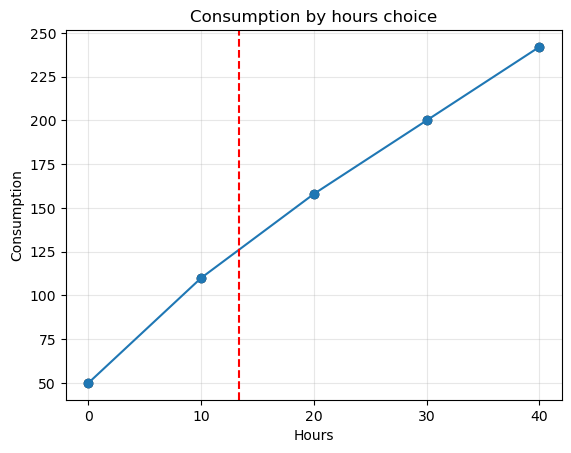

In [4]:
# Plot consumption (vertical) over hours choices (horizontal):
plt.plot(hours_options, consump, marker="o", linestyle="-")
plt.scatter(hours_options, consump, color="black")
plt.xlabel("Hours")
plt.ylabel("Consumption")
plt.title("Consumption by hours choice")
plt.xticks(hours_options)
plt.grid(True, alpha=0.3)
plt.axvline(80 / hourly_wage, color="red", linestyle="--", label="Tax kink")
plt.show()

**1.4** Discuss the role of each preference parameter ($\theta$, $\alpha$, $\gamma$) in the utility function. What does $\gamma$ govern relative to the preference shock $\varepsilon_{ij}$?

- $\theta$: CRRA curvature of consumption utility, governs diminishing marginal utility of consumption. As $\theta \to 0$, $\frac{c^{\theta}}{\theta} \to \ln(c)$.

- $\alpha$: Disutility of work, linear in hours. Higher alpha raises the attractiveness of non-participation/less hours relative to working alternatives.

- $\gamma$: Scales the coefficients of the systematic utility component (from consumption and leisure) relative to the variance of the type-1 EV errors. For more details on the 'scale parameter', see Train (2009) Section 3.2.  

**Identification / normalisation**: only the product $\gamma\alpha$ is identified from cross-sectional choice data — multiplying $\gamma$ by a constant and dividing $\alpha$ by the same constant leaves all choice probabilities unchanged. Therefore $\gamma$ and $\alpha$ are not separately identified, and we must normalise $\gamma = 1$. Under this normalisation, $\alpha$ is interpreted as the disutility of work in units of consumption utility.

**1.5** What does this model abstract from? List at least three dimensions and, for each, briefly indicate how the omission may affect policy conclusions.

- Demand-side/job-offer constraints on labor-supply decisions: hours choices modelled as entirely voluntarily and solely dependent on individual preference parameters and earnings potential. No rationing-risk or employer-side restrictions. This may lead to an overstatement of labour supply elasticities. For an application, extending a model similar to the one discussed here see Bargain et al., 2010 "Making work pay in a rationed labor market".

- Other fixed costs of work (e.g. childcare, commuting): omitting them may bias alpha upward for non-participants and flattens the extensive margin

- Household and family labor supply: ignores spouse income and joint decision making; cross-wage effects can be quantitatively important for policy evaluations

- Dynamics and human capital accumulation: current labor supply choices have dynamic implications in terms of experience/human capital accumulation and future earnings (see next problem set)


## Problem 2: Simulating a dataset

Using the data generating process above, simulate a cross-sectional dataset and explore basic properties of the model.

**2.1** Using the data generating process above, simulate a cross-sectional dataset of $N = 10{,}000$ individuals comprising each individual's hours worked $h_i$, non-labour income $y_i$, labour earnings $\omega_i \cdot h_i$, and hourly wage $\omega_i$. Note that wages are observed only for workers ($h_i > 0$).

#### Define parameters
We store all structural parameters of the model and the model specification in some object, e.g. a dictionary. In more complex applications it might be even preferable to split the two.

In [5]:
# Define dict:
calib = {
    'alpha': 0.1,
    'gamma': 1.0,
    'theta': 0.3,
    'mean_wagerate': 1.0,       # mu_w
    'sd_wagerate': 0.55,        # sigma_w
    'tax_threshold': 80,
    'tax_rate': 0.3,
    'possible_hours': np.array([0, 10, 20, 30, 40]),
    'num_possible_hours': 5,
    'sim_num_obs': 10000,
    'sim_seed': 123   
}
calib

{'alpha': 0.1,
 'gamma': 1.0,
 'theta': 0.3,
 'mean_wagerate': 1.0,
 'sd_wagerate': 0.55,
 'tax_threshold': 80,
 'tax_rate': 0.3,
 'possible_hours': array([ 0, 10, 20, 30, 40]),
 'num_possible_hours': 5,
 'sim_num_obs': 10000,
 'sim_seed': 123}

#### Define function to simulate utilities

In [6]:
def calculate_non_random_utility_for_hours(
    hours_options, hourly_wage_individuals, non_labor_income_individuals, calib
):
    """Calculate utility for each hour choice option.

    Parameters
    ----------
    hours_options : np.ndarray
        Array of possible hours options. Shape is (num_hours_options,).
    hourly_wage_individuals : np.ndarray
        Array of hourly wage rates. Shape is (num_obs,).
    non_labor_income_individuals : np.ndarray
        Array of non-labor income. Shape is (num_obs,).
    parameters (class)

    Returns
    -------
    utility : np.ndarray
        Array of utility for each hour choice option. Of shape (num_obs, num_hours_options).

    """
    # Read utility parameters
    alpha = calib["alpha"]
    gamma = calib["gamma"]
    theta = calib["theta"]

    # Read tax parameters
    tax_threshold = calib["tax_threshold"]
    tax_rate = calib["tax_rate"]

    # Calculate labor income for each hour choice
    labor_income = np.outer(hourly_wage_individuals, hours_options)

    # Apply tax function to labor income
    taxes = np.where(
        labor_income > tax_threshold,
        tax_rate * (labor_income - tax_threshold),
        0,
    )

    # Calculate consumption for each hour choice. To add non-labor income to each column
    # representing each hour option, we need to add a new axis to non_labor_income,
    # which creates a column vector.
    consumption = labor_income + non_labor_income_individuals[:, np.newaxis] - taxes

    # Calculate utility for each hour choice
    utility = gamma * (consumption**theta / theta - alpha * hours_options)
    return utility

#### Generate draws for wage earnings and non-labor income; compute simulated utilities

In [7]:
# Set seed for reproducibility
np.random.seed(calib["sim_seed"])

# Draw random taste shocks
taste_shocks = np.random.gumbel(loc=0, scale=1, size=(calib["sim_num_obs"], calib["num_possible_hours"]))
# Draw non-labor income
non_labor_income = np.random.uniform(low=10, high=100, size=calib["sim_num_obs"])
# Draw wage shocks
wage_shocks = np.random.normal(loc=0, scale=calib["sd_wagerate"], size=calib["sim_num_obs"])
# Construct wage rates
wage_rate = np.exp(calib["mean_wagerate"] + wage_shocks)

# generate individual choices using random draws from the uniform distribution [0,1] (alternative simulation approach see below)
logit_prob_draw = np.random.uniform(low=0, high=1, size=calib["sim_num_obs"])

#### Method 1: arg-max with Gumbel draws

In [8]:
# Generate individual utilities by adding systematic subutility and Gumbel taste shock draws
def calculate_opt_choice_gumbel(taste_shocks, non_labor_income, wage_rate, calib):
    
    # compute utility from all hours options
    utilities_hour_options = (
        calculate_non_random_utility_for_hours(
            hours_options=calib["possible_hours"],
            hourly_wage_individuals=wage_rate,
            non_labor_income_individuals=non_labor_income,
            calib=calib,
        )
        + taste_shocks
    )

    # Determine optimal hourly choices
    optimal_choice = np.argmax(utilities_hour_options, axis=1)

    return optimal_choice

#### Alternative Method 2: inverse-cdf method
An alternative way to compute optimal choices is to exploit the fact that the random utility model specification with Gumbel EV-1 errors has closed-form expressions for the choice probabilities (recall lecture on IO-dynamicDC).
Thus we can compute choice probabilities from systematic utility components and derive optimal choices by drawing from a uniform distribution.


In [9]:
# Alternative: inverse-cdf method

def calculate_opt_choice_logit(logit_prob_draw, non_labor_income, wage_rate, calib):

    # Compute systematic utility without adding Gumbel type shock
    utilities_hour_options =  calculate_non_random_utility_for_hours(
        hours_options=calib["possible_hours"],
        hourly_wage_individuals=wage_rate,
        non_labor_income_individuals=non_labor_income,
        calib=calib,
    )

    # Before taking exponentials, it is helpful to rescale utilities to avoid numerical over/underflows. Note that only relative differences in systematic utility determine choice probabilities.
    rescaled_utilities =  utilities_hour_options - utilities_hour_options.max(axis=1, keepdims=True)    

    # exponentiate utilities
    exp_utilities = np.exp(rescaled_utilities)

    # compute closed-form logit choice probabilities
    choice_probs = exp_utilities / exp_utilities.sum(axis=1, keepdims=True)

    # generate cumulative probability sum
    choice_prob_sum = choice_probs.cumsum(axis=1)

    # assert that choice probabilities sum to 1
    print(np.allclose(choice_prob_sum[:,4],1))

    # derive optimal choices; vectorised: index of first cum-prob >= draw from uniform [0,1]
    optimal_choice_logit = np.argmax(choice_prob_sum >= logit_prob_draw[:, None], axis=1)

    return optimal_choice_logit


In [12]:
# Run both simulation procedures an compare choice frequencies
opt_choice_gumbel = calculate_opt_choice_gumbel(taste_shocks, non_labor_income, wage_rate, calib)

opt_choice_logit = calculate_opt_choice_logit(logit_prob_draw, non_labor_income, wage_rate, calib)

# Compare choice frequencies:
comparison = pd.DataFrame({
    "Hours":      calib["possible_hours"],
    "Gumbel (%)": [(opt_choice_gumbel == j).mean() * 100 for j in range(calib["num_possible_hours"])],
    "Logit (%)":  [(opt_choice_logit == j).mean() * 100 for j in range(calib["num_possible_hours"])],
})
print(comparison.round(2))

True
   Hours  Gumbel (%)  Logit (%)
0      0       15.97      16.23
1     10       20.83      20.89
2     20       23.81      23.80
3     30       21.92      21.75
4     40       17.47      17.33


**Note:** the two procedures do NOT produce identical choices at the individual level. The argmax-of-Gumbel method and the inverse-CDF method both draw from the SAME model, so they agree in distribution, not draw-by-draw; empirical choice frequencies therefore converge as the sample size grows.

#### Save dataset

In [13]:
# Define DataFrame
data = pd.DataFrame(index=range(calib["sim_num_obs"]))

# Save non-labor income, choice and hours
data["non_labor_income"] = non_labor_income
data["choice"] = opt_choice_gumbel
data["hours"] = calib["possible_hours"][opt_choice_gumbel]

# Save labor income. Note for non-workers, we have zero hours and therefore zero income
data["labor_income"] = data["hours"] * wage_rate
# Save hourly wage. For non-workers we do not observe wages in reality, so we set them to NaN
data["hourly_wage"] = np.nan
# wage_rate is already aligned to individual i; assign it, then blank out non-workers
data["hourly_wage"] = np.where(data["hours"].values != 0, wage_rate, np.nan)
data

,non_labor_income,choice,hours,labor_income,hourly_wage
0,42.477892,2,20,48.914944,2.445747
1,30.282111,4,40,200.676130,5.016903
2,55.731740,3,30,24.228501,0.807617
3,64.511552,2,20,85.917024,4.295851
4,60.914680,0,0,0.000000,NaN
...,...,...,...,...,...
9995,61.186499,0,0,0.000000,NaN
9996,32.962516,0,0,0.000000,NaN
9997,13.199761,4,40,276.808576,6.920214
9998,45.448150,2,20,95.925570,4.796278


<Axes: >

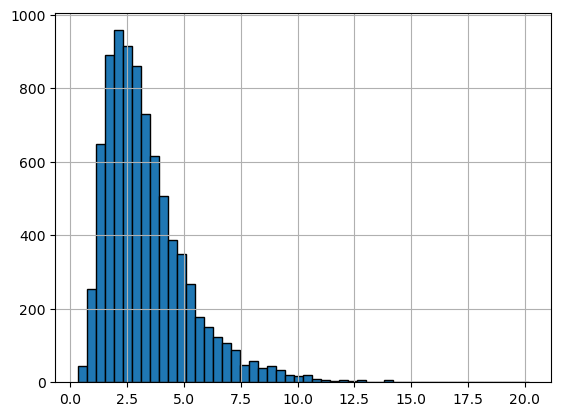

In [14]:
data["hourly_wage"].hist(bins=50, edgecolor="black")

<Axes: >

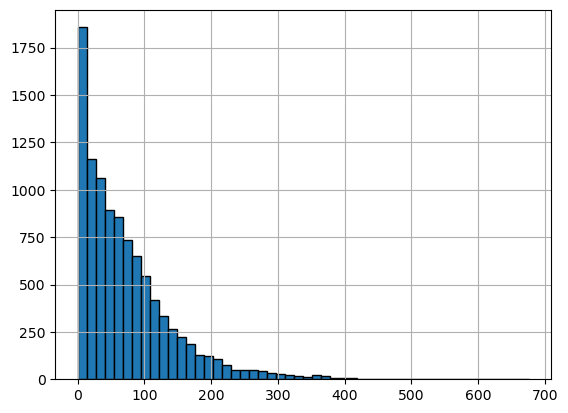

In [15]:
data["labor_income"].hist(bins=50, edgecolor="black")

**2.2** Plot the distribution of work hours across the five alternatives. How do average non-labour income and average wages vary across hours categories?

In [16]:
# Hours in percentage
data["hours"].value_counts(normalize=True)

hours
20    0.2381
30    0.2192
10    0.2083
40    0.1747
0     0.1597
Name: proportion, dtype: float64

In [17]:
# Average non-labor income by hours:
print("Corr(non_labor_income, hours):", data["non_labor_income"].corr(data["hours"]))
data.groupby("hours")["non_labor_income"].mean()

Corr(non_labor_income, hours): -0.21980605062418268


hours
0     65.543857
10    57.955036
20    53.753167
30    49.684901
40    47.930087
Name: non_labor_income, dtype: float64

In [18]:
# Average wages by hours:
print("Corr(hourly_wage, hours):", data["hourly_wage"].corr(data["hours"]))
data.groupby("hours")["hourly_wage"].mean()

Corr(hourly_wage, hours): 0.20610592294792135


hours
0          NaN
10    2.764400
20    3.295224
30    3.590750
40    3.876727
Name: hourly_wage, dtype: float64

##### Notes: extensive vs. intensive margin
- **Non-labour income** relates mainly to the **extensive margin**: higher $y_i$ raises consumption at $h=0$ relative to working alternatives (an income effect on participation), so $\text{Corr}(y_i, h_i)<0$.
- **Wages** operate on the **intensive margin** among workers: a higher $\omega_i$ raises the consumption payoff of each extra hour, shifting mass toward longer hours. Wages are unobserved at $h=0$, so this correlation is computed on workers only.
- Keeping the two margins distinct is useful for the counterfactual below: the threshold reform acts on both. Some individuals leave employment (extensive), others merely reduce hours (intensive).

**2.3** Compute baseline tax revenue.

In [19]:
# Taxes paid at each individual's observed hours choice
labor_income_baseline = wage_rate * calib["possible_hours"][data["choice"]]
taxes_baseline = np.where(
    labor_income_baseline > calib["tax_threshold"],
    calib["tax_rate"] * (labor_income_baseline - calib["tax_threshold"]),
    0,
)
revenue_baseline = taxes_baseline.sum()
print(f"Baseline tax revenue: €{revenue_baseline:,.1f}")

Baseline tax revenue: €70,718.2


## Problem 3: Estimation of preference parameters

**3.1** Write down the log-likelihood function to estimate $(\alpha, \gamma, \theta)$. What problem arises for non-workers, and how would you address it?

The likelihood function is defined as the joint probability of observing an individuals' decisions (in this case, hours worked), given their characteristics (such as non-labor income and wages) and the structural parameters. Given the Type-I extreme value assumption on the preference shocks $\varepsilon_{ij}$, McFadden (1973) shows that the probability of individual $i$ choosing hours alternative $j$ has the closed-form **multinomial logit** expression:

\begin{align*}
       P(h_{ij} \mid y_i, \omega_i;\, \alpha, \gamma, \theta) = \frac{\exp\!\left[u(h_{ij}, y_i, \omega_i;\, \alpha, \gamma, \theta)\right]}{\sum_{h \in \{0, 10, 20, 30, 40\}}\exp\!\left[u(h_{ij'}, y_i, \omega_i;\, \alpha, \gamma, \theta)\right]}
\end{align*}

where the systematic utility at alternative $j$ is:

\begin{align*}
       u(h_{ij}, y_i, \omega_i;\, \alpha, \gamma, \theta) = \gamma \left[ \frac{c_{ij}^\theta}{\theta} - \alpha\, h_{ij}\right], \qquad c_{ij} = y_i + \omega_i h_{ij} - T(\omega_i h_{ij})
\end{align*}

The **likelihood** function for a cross-section of $N$ individuals is given by:
\begin{align*}
       L(h_1,...,h_N \mid y_1,...,y_N, \omega_1,...,\omega_N;  \alpha, \gamma, \theta) = \prod_{i=1}^{N}  P(h_i \mid y_i, \omega_i;\, \alpha, \gamma, \theta)
\end{align*}

The **log-likelihood** sums the log probability of each individual's observed choice:

$$\ell(\alpha, \gamma, \theta)
= \sum_{i=1}^{N} \ln P(h_i \mid y_i, \omega_i;\, \alpha, \gamma, \theta)$$

---

**Problem for non-workers ($h_i = 0$):** The wage $\omega_i$ is unobserved for non-working individuals, so we cannot evaluate $P(h_i = 0 \mid \cdot)$ directly. Evaluation of the denominator requires computation of systematic utilities at positive hours and wage-rate implied labor earnings.

**Fix:** Impute the sample mean wage of *observed* workers as the counterfactual wage for non-workers. This gives a single wage value for every individual, so the denominator can be evaluated for everyone.

**Caveat (selection).** Non-workers are not a random subsample: individuals with low wage draws are more likely to choose $h_i=0$, so the observed-worker wage distribution is upward-selected. Imputing the *worker* mean therefore overstates the counterfactual wage of the average non-worker and introduces measurement error into their consumption at positive-hours alternatives. Here the bias is mild because wages are drawn independently of the taste shocks and enter utility only through the budget; in applications with rich selection this is precisely the problem addressed by wage-equation/selection corrections (Heckman-type or the van Soest joint specification).

---

**Note on explicit indicator form (credits to solution presented by Daniela Erler & Vanessa Brandes).** The sample likelihood can be written with with choice indicators $d_{ij}=\mathbb{1}\{h_i=h_{ij}\}$ before collapsing to the observed choice:

$$L(\alpha,\gamma,\theta)=\prod_{i=1}^{N}\prod_{j\in J} P(h_{ij}\mid\cdot)^{d_{ij}}
\quad\Longrightarrow\quad
\ell=\sum_{i}\sum_{j} d_{ij}\Big(V_{ij}-\ln\!\sum_{k} e^{V_{ik}}\Big),
\qquad V_{ij}=\tfrac{c_{ij}^\theta}{\theta}-\alpha h_{ij}.$$

This is identical to $\sum_i \ln P(h_i\mid\cdot)$ above, but makes the map to the code (log-sum-exp, then pick the chosen column) explicit.

**3.2** Implement the log-likelihood and estimate the model using the simulated dataset. To keep the exercise simple and well-identified, **fix $\theta = 0.3$** (its true value) and $\gamma = 1$, and estimate only the disutility parameter $\alpha$. Report the estimated $\alpha$ and verify that it is close to the true value used for simulation.

### Identification note: why we fix $\gamma$ and $\theta$

The choice probabilities are multinomial logit in the systematic utility $U_{ij} = \gamma\left[\frac{c_{ij}^\theta}{\theta} - \alpha h_{ij}\right]$. Two identification issues arise, both stemming from the fact that **only utility *differences across alternatives*, measured relative to the (normalised) Gumbel error scale, drive the likelihood**:

- **$\gamma$ is not separately identified:** $\gamma$ multiplies the *entire* deterministic utility, so it is indistinguishable from the scale of the taste shocks. Only the products $\gamma \cdot (\text{consumption term})$ and $\gamma\alpha$ affect choice probabilities. We therefore normalise $\gamma = 1$ which is free in the sense that it is not an assumption about behaviour (relative choice selection across alternatives).

- **$\alpha$ and $\theta$ trade off along a near-flat likelihood ridge (weak identification):** Curvature $\theta$ and hours-disutility $\alpha$ generate very similar patterns of choice probabilities: a lower $\theta$ can be almost perfectly offset by a lower $\alpha$ in this simple setup. The likelihood is nearly flat along this ridge, so estimating both jointly recovers neither reliably. Te optimiser slides down the ridge, typically driving $\theta \to 0$. Fixing $\theta$ at its true value removes the ridge and lets $\alpha$ be recovered cleanly. This mirrors empirical practice, where CRRA/curvature parameters are routinely calibrated rather than estimated.

- **Remember:** "Recovering" a parameter under tight bounds or a single starting value is *not* evidence of identification. Always probe the likelihood surface (profile over the parameter, use wide bounds and multiple starts). Examine how the likelihood/criterion function responds to changes in single parameters. Separately identifying $\theta$ would require variation shifting the marginal utility of consumption independently of hours, e.g. exogenous non-labour-income variation with panel/repeated choices. Such variation is not constructed by the DGP we calibrated.

In [20]:
# ============================================================================
# NOTE: The log-likelihood function below is specified general enough to allow for estimation of/optimization over both alpha, theta. 
# The estimation passes a fixed theta.
# ============================================================================

# --- Step 1: impute mean worker wage for non-workers ---
mean_worker_wage = data.loc[data["hours"] > 0, "hourly_wage"].mean()
data.loc[data["hours"] == 0, "hourly_wage"] = mean_worker_wage

# --- Step 2: define the negative log-likelihood ---
def log_likelihood(utility_params, hours_options, wage_data, non_labor_income_data,
                   choice_data, tax_threshold, tax_rate):
    """Negative log-likelihood for the multinomial logit labour supply model.

    Parameters
    ----------
    utility_params : array-like, shape (2,)
        Trial values [alpha, theta] to evaluate. gamma=1 is fixed for identification.
    hours_options : np.ndarray
        Discrete hours alternatives.
    wage_data, non_labor_income_data : np.ndarray
        Individual wages (workers) / imputed mean (non-workers) and non-labour income.
    choice_data : np.ndarray
        Index of the observed hours choice for each individual.
    tax_threshold, tax_rate : float
        Fixed tax system parameters.

    Returns
    -------
    float
        Negative sum of log choice probabilities (for minimisation).
    """
    alpha, theta = utility_params   # gamma=1 normalised: not estimated

    # Consumption at each hours alternative: c = y + w*h - T(w*h)
    labor_income = np.outer(wage_data, hours_options)            # shape (N, J)
    taxes = np.where(
        labor_income > tax_threshold,
        tax_rate * (labor_income - tax_threshold),
        0,
    )
    consumption = labor_income + non_labor_income_data[:, np.newaxis] - taxes  # (N, J)

    # Systematic utility at each alternative (gamma=1)
    utilities = consumption**theta / theta - alpha * hours_options             # (N, J)

    # Logit probabilities — subtract row-max for numerical stability (cancels in ratio)
    utilities -= utilities.max(axis=1, keepdims=True)
    exp_u = np.exp(utilities)
    choice_probs = exp_u / exp_u.sum(axis=1, keepdims=True)                    # (N, J)

    # Log probability of the observed choice for each individual
    log_prob = np.log(choice_probs[np.arange(len(choice_data)), choice_data])

    return -log_prob.sum()   # return negative for minimisation

# --- Step 3: fix data arguments, leave only utility_params free ---
partial_loglike = partial(
    log_likelihood,
    hours_options=calib["possible_hours"],
    wage_data=data["hourly_wage"].values,
    non_labor_income_data=data["non_labor_income"].values,
    choice_data=data["choice"].values,
    tax_threshold=calib["tax_threshold"],
    tax_rate=calib["tax_rate"],
)

# --- Step 4: maximise likelihood via scipy (minimise negative log-likelihood) ---
# theta = 0.3 and gamma = 1 are FIXED at true values; only alpha is estimated.
theta_fixed = calib["theta"]

def partial_loglike_alpha(alpha_param):
    """Negative log-likelihood as a function of alpha only (theta fixed)."""
    return partial_loglike(np.array([alpha_param[0], theta_fixed]))

result = minimize(
    partial_loglike_alpha,
    x0=np.array([0.5]),                  # starting value for alpha
    bounds=[(1e-6, 1.0)],                # alpha
    method="L-BFGS-B",
)

# --- Step 5: report results ---
alpha_hat = result.x[0]
theta_hat = theta_fixed
print(f"Optimiser converged: {result.success}  ({result.message})")
print(f"(theta fixed at {theta_fixed}, gamma = 1 normalised)")
print()
print(f"{'Parameter':<10} {'True':>8} {'Estimated':>12}")
print("-" * 32)
print(f"{'alpha':<10} {calib['alpha']:>8.3f} {alpha_hat:>12.4f}")
print(f"{'theta':<10} {calib['theta']:>8.3f} {theta_hat:>12.4f}  (fixed)")

Optimiser converged: True  (CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH)
(theta fixed at 0.3, gamma = 1 normalised)

Parameter      True    Estimated
--------------------------------
alpha         0.100       0.1052
theta         0.300       0.3000  (fixed)


### Inference: a standard error for $\hat\alpha$
The estimates above are point estimates. Under standard regularity conditions the ML estimator is asymptotically normal with variance equal to the inverse information matrix. Two common sample analogues are the numerical Hessian of the log-likelihood and the outer product of the individual score contributions (OPG / BHHH). Below we report the OPG standard error for $\hat\alpha$ (with $\theta,\gamma$ fixed), obtained by numerically differentiating each individual's log-likelihood contribution.

In [21]:
# OPG (BHHH) standard error for alpha, with theta and gamma fixed.
def indiv_loglik_alpha(alpha):
    """Vector of individual log-likelihood contributions at a scalar alpha (theta fixed)."""
    w = data["hourly_wage"].values
    y = data["non_labor_income"].values
    ch = data["choice"].values
    h = calib["possible_hours"]
    labor_income = np.outer(w, h)
    taxes = np.where(labor_income > calib["tax_threshold"],
                     calib["tax_rate"] * (labor_income - calib["tax_threshold"]), 0)
    c = labor_income + y[:, None] - taxes
    u = c**theta_fixed / theta_fixed - alpha * h
    u -= u.max(axis=1, keepdims=True)
    p = np.exp(u); p /= p.sum(axis=1, keepdims=True)
    return np.log(p[np.arange(len(ch)), ch])

# Numerical score per individual: d log L_i / d alpha
eps = 1e-5
scores = (indiv_loglik_alpha(alpha_hat + eps) - indiv_loglik_alpha(alpha_hat - eps)) / (2 * eps)

opg = (scores**2).sum()          # outer product of gradients (scalar here)
se_alpha = 1.0 / np.sqrt(opg)     # asymptotic SE = sqrt(inverse information)

print(f"alpha_hat = {alpha_hat:.4f}   OPG std. error = {se_alpha:.4f}")
print(f"Approx. 95% CI: [{alpha_hat - 1.96*se_alpha:.4f}, {alpha_hat + 1.96*se_alpha:.4f}]")
print(f"(true alpha = {calib['alpha']:.3f})")

alpha_hat = 0.1052   OPG std. error = 0.0008
Approx. 95% CI: [0.1037, 0.1067]
(true alpha = 0.100)


True parameter alpha falls outside of 95% CI, why? This is the mostly down to the bias we introduced by imputing averages wages for the non-employed.

In [22]:
# Illustration: alpha and theta are NOT separately recovered.
# Starting from an interior point and letting BOTH vary, the optimiser slides down the near-flat ridge and drives theta toward its lower bound while alpha adjusts to compensate -- neither is pinned down.
res_joint = minimize(
    partial_loglike,
    x0=np.array([0.5, 0.5]),                 # [alpha, theta]
    bounds=[(1e-6, 1.0), (1e-6, 1.0)],
    method="L-BFGS-B",
)
print(f"Joint (alpha, theta) estimate: alpha={res_joint.x[0]:.4f}, theta={res_joint.x[1]:.4f}")
print(f"True values:                   alpha={calib['alpha']:.4f}, theta={calib['theta']:.4f}")
print("-> theta collapses toward the lower bound; alpha is displaced to compensate.")

Joint (alpha, theta) estimate: alpha=0.0398, theta=0.0858
True values:                   alpha=0.1000, theta=0.3000
-> theta collapses toward the lower bound; alpha is displaced to compensate.


**Visualising the ridge.** Rather than take the weak-identification claim on faith, we can *see* it. For a grid of fixed $\theta$ values we re-optimise $\alpha$ and plot the resulting profile log-likelihood $\ell(\theta, \hat\alpha(\theta))$. A profile that is nearly flat over a wide range of $\theta$ means the data cannot distinguish those $(\theta, \alpha)$ combinations.

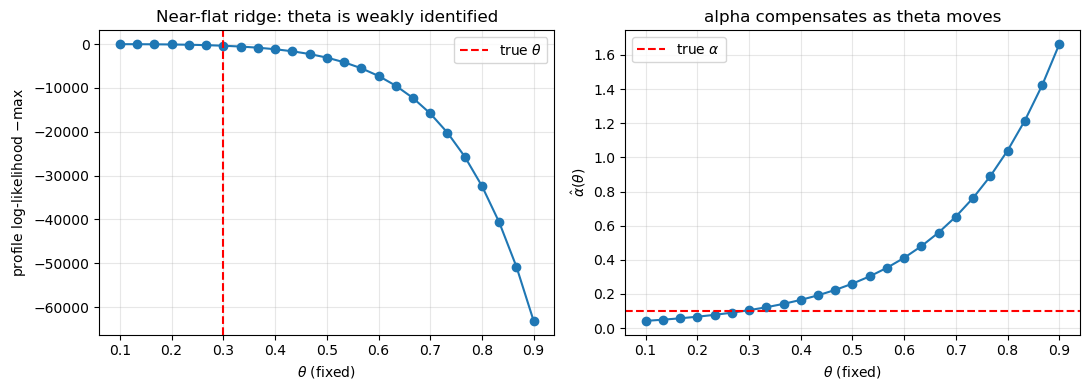

Total variation in profile log-likelihood over theta in [0.1, 0.9]: 63,150.8
(N = 10000). A small range relative to N signals a flat ridge:
many (theta, alpha) pairs fit almost equally well, so theta cannot be pinned down.


In [23]:
# Profile the log-likelihood over theta: for each fixed theta, re-optimise alpha.
theta_grid = np.linspace(0.10, 0.90, 25)
profile_ll = np.empty_like(theta_grid)
alpha_at_theta = np.empty_like(theta_grid)

for k, th in enumerate(theta_grid):
    res_k = minimize(
        lambda a: partial_loglike(np.array([a[0], th])),
        x0=np.array([0.1]),
        bounds=[(1e-6, 2.0)],
        method="L-BFGS-B",
    )
    alpha_at_theta[k] = res_k.x[0]
    profile_ll[k] = -res_k.fun            # back to log-likelihood (we minimise the negative)

# Plot the profile log-likelihood (normalised to its max = 0 for readability)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(theta_grid, profile_ll - profile_ll.max(), marker="o")
ax[0].axvline(calib["theta"], color="red", linestyle="--", label=r"true $\theta$")
ax[0].set_xlabel(r"$\theta$ (fixed)")
ax[0].set_ylabel(r"profile log-likelihood $-\max$")
ax[0].set_title("Near-flat ridge: theta is weakly identified")
ax[0].legend(); ax[0].grid(True, alpha=0.3)

ax[1].plot(theta_grid, alpha_at_theta, marker="o")
ax[1].axhline(calib["alpha"], color="red", linestyle="--", label=r"true $\alpha$")
ax[1].set_xlabel(r"$\theta$ (fixed)")
ax[1].set_ylabel(r"$\hat\alpha(\theta)$")
ax[1].set_title("alpha compensates as theta moves")
ax[1].legend(); ax[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

ll_range = profile_ll.max() - profile_ll.min()
print(f"Total variation in profile log-likelihood over theta in [0.1, 0.9]: {ll_range:,.1f}")
print(f"(N = {calib['sim_num_obs']}). A small range relative to N signals a flat ridge:")
print("many (theta, alpha) pairs fit almost equally well, so theta cannot be pinned down.")

**3.3** Compare observed and predicted hours-choice frequencies following van Soest (1995, Table 3). A validated fit justifies using the estimated parameters for the counterfactual exercise in Problem 4.

*(Note: because the data are generated from the same parametric model, the homogeneous worker model fits the simulated data well here. Problem 5 revisits this comparison on a dataset with unobserved type heterogeneity, where the homogeneous worker model falls short — motivating the finite-mixture extension.)*

In [24]:
# Recompute choice probabilities at estimated parameters (gamma=1 fixed)
labor_income = np.outer(data["hourly_wage"].values, calib["possible_hours"])
taxes = np.where(
    labor_income > calib["tax_threshold"],
    calib["tax_rate"] * (labor_income - calib["tax_threshold"]),
    0,
)
consumption = labor_income + data["non_labor_income"].values[:, np.newaxis] - taxes

utilities_hat = consumption**theta_hat / theta_hat - alpha_hat * calib["possible_hours"]
utilities_hat -= utilities_hat.max(axis=1, keepdims=True)
exp_u_hat = np.exp(utilities_hat)
choice_probs_hat = exp_u_hat / exp_u_hat.sum(axis=1, keepdims=True)   # shape (N, J)

# Observed vs predicted frequencies (in percent)
obs_pct  = np.array([(data["hours"] == h).mean() * 100 for h in calib["possible_hours"]])
pred_pct = choice_probs_hat.mean(axis=0) * 100
    # Note: predicted choice frequencies can be directly computed as average predicted choice-probabilities cond. on the data

# Van Soest (1995, Table 3) style fit table
fit_table = pd.DataFrame({
    "Hours":          calib["possible_hours"],
    "Observed (%)":   np.round(obs_pct,  1),
    "Predicted (%)":  np.round(pred_pct, 1),
})
fit_table

,Hours,Observed (%),Predicted (%)
0,0,16.0,15.0
1,10,20.8,21.3
2,20,23.8,25.0
3,30,21.9,22.1
4,40,17.5,16.6


## Problem 4: Counterfactual policy simulation

A key advantage of structural estimation is that the recovered parameters can be used to simulate counterfactual outcomes under alternative policies, holding individual characteristics fixed. Using the preference parameters estimated in Problem 3:

**4.1** The government is considering lowering the tax-free earnings threshold from €80 to €50 per week, keeping the marginal tax rate at $t = 0.3$. Simulate the behavioural response by applying this reform to the individuals in the baseline dataset, i.e. holding the calibrated wages, non-labour income, and taste shocks fixed.

In [25]:
# --- Define the reform tax system ---
# Reform: lower the tax-free earnings threshold from €80 to €50
# Note: simulated wages are unchanged, thus only the available consumption changes via the changes to the budget
#   - for comparability we re-use the originally drawn taste-shocks
# -> Re-compute individual utilities and implied optimal choices under the reform.

# Replace tax_threshold in calib dict
calib["tax_threshold"] = 50

# Replace calibrated preference parameters with estimates (alpha_hat)
#   - in a real application, the preference parameters are unknown and estimated from the data
#   - assuming we have validated the model fit to our satisfaction, we treat the estimated structural parameters as 'policy-invariant', i.e. as determining behavior independent of the policy/economic environment (here defined as the tax-transfer function)
calib["alpha"] = alpha_hat


# --- Simulate reform choices: same wages, income, and taste shocks ---
# Reuse calculate_non_random_utility_for_hours with the reform parameters
utilities_reform = (
    calculate_non_random_utility_for_hours(
        hours_options=calib["possible_hours"],
        hourly_wage_individuals=wage_rate,
        non_labor_income_individuals=non_labor_income,
        calib=calib,
    )
    + taste_shocks   # same preference shocks as in the baseline
)

# Optimal hours choice under the reform
optimal_choice_reform = np.argmax(utilities_reform, axis=1)
hours_reform = calib["possible_hours"][optimal_choice_reform]

# Summary: how many individuals switch hours category?
n_switchers = (optimal_choice_reform != data["choice"]).sum()
print(f"Individuals who switch hours category: {n_switchers} / {calib['sim_num_obs']} "
      f"({100 * n_switchers / calib['sim_num_obs']:.1f}%)")

# Restore the baseline threshold in calib so later cells are unaffected by this experiment.
calib["tax_threshold"] = 80

Individuals who switch hours category: 660 / 10000 (6.6%)


**4.2** Plot and compare the distribution of hours worked under the reform against the baseline from Problem 2.

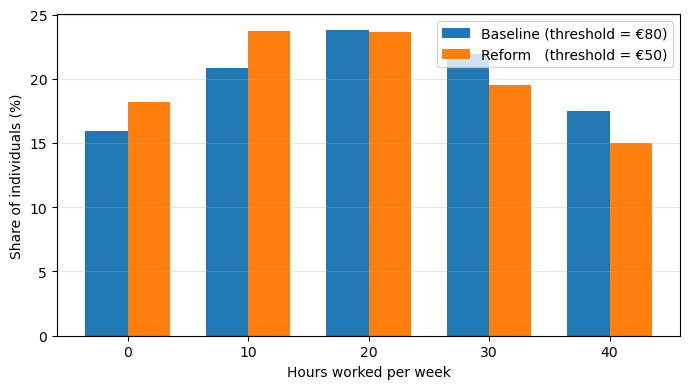

,Hours,Baseline (%),Reform (%),Change (pp)
0,0,16.0,18.2,2.2
1,10,20.8,23.7,2.9
2,20,23.8,23.6,-0.2
3,30,21.9,19.5,-2.4
4,40,17.5,15.0,-2.5


In [26]:
# Compute hours frequencies under baseline and reform
hours_baseline  = calib["possible_hours"][data["choice"]]
baseline_pct    = np.array([(hours_baseline == h).mean() * 100 for h in calib["possible_hours"]])
reform_pct      = np.array([(hours_reform    == h).mean() * 100 for h in calib["possible_hours"]])

# --- Side-by-side bar chart ---
x     = np.arange(len(calib["possible_hours"]))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width / 2, baseline_pct, width=width, label="Baseline (threshold = €80)")
ax.bar(x + width / 2, reform_pct,   width=width, label="Reform   (threshold = €50)")
ax.set_xticks(x)
ax.set_xticklabels(calib["possible_hours"])
ax.set_xlabel("Hours worked per week")
ax.set_ylabel("Share of individuals (%)")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# --- Comparison table ---
pd.DataFrame({
    "Hours":         calib["possible_hours"],
    "Baseline (%)":  np.round(baseline_pct, 1),
    "Reform (%)":    np.round(reform_pct,   1),
    "Change (pp)":   np.round(reform_pct - baseline_pct, 1),
})

##### Notes:
- The reform lowers the tax-free threshold from €80 to €50, so a larger portion of earnings is taxed at the margin. This reduces the consumption payoff of working, especially at the higher-hours alternatives that previously sat below (or nearer) the old threshold.
- The behavioural response has the expected sign: some individuals move to fewer hours or out of employment. Its magnitude reflects the calibrated preference parameters and the coarse hours grid. With five alternatives, responses appear as discrete category switches rather than smooth adjustments.

**4.3** Compute tax revenue under the reform. Decompose the change relative to the baseline into a *mechanical effect* (revenue change at unchanged behaviour) and a *behavioural effect* (additional revenue change due to labour supply adjustment).

In [27]:
def compute_taxes(wages, hours, tax_threshold, tax_rate):
    """Taxes paid by each individual given wages, hours, and the tax function."""
    labor_income = wages * hours
    return np.where(
        labor_income > tax_threshold,
        tax_rate * (labor_income - tax_threshold),
        0,
    )

# (a) Baseline revenue: baseline choices, baseline tax system
#     (already computed in Problem 2.3; reproduced here for clarity)
taxes_base = compute_taxes(wage_rate, hours_baseline, 80, calib["tax_rate"])
revenue_base = taxes_base.sum()

# (b) Mechanical revenue: baseline choices, reform tax system
#     —> answers "what if only the tax changes, not behaviour?"
taxes_mechanical = compute_taxes(wage_rate, hours_baseline, 50, calib["tax_rate"])
revenue_mechanical = taxes_mechanical.sum()

# (c) Reform revenue: reform choices, reform tax system
taxes_reform = compute_taxes(wage_rate, hours_reform, 50, calib["tax_rate"])
revenue_reform = taxes_reform.sum()

# --- Decomposition ---
mechanical_effect  = revenue_mechanical - revenue_base   # >0: more income now taxable
behavioural_effect = revenue_reform - revenue_mechanical  # <0: people work less
total_change       = revenue_reform - revenue_base        # mechanical + behavioural

print(f"{'':35} {'€':>10}")
print("-" * 46)
print(f"{'Baseline tax revenue':<35} {revenue_base:>10,.1f}")
print(f"{'Reform tax revenue':<35} {revenue_reform:>10,.1f}")
print("-" * 46)
print(f"{'Total change':<35} {total_change:>+10,.1f}")
print(f"  {'of which: mechanical effect':<33} {mechanical_effect:>+10,.1f}")
print(f"  {'of which: behavioural effect':<33} {behavioural_effect:>+10,.1f}")

                                             €
----------------------------------------------
Baseline tax revenue                  70,718.2
Reform tax revenue                   101,180.8
----------------------------------------------
Total change                         +30,462.5
  of which: mechanical effect        +39,197.9
  of which: behavioural effect        -8,735.4


## Problem 5: Unobserved individual heterogeneity

Observed heterogeneity (e.g. education, experience) can be incorporated directly into the wage equation. Structural models can additionally capture *unobserved* time-invariant heterogeneity using a finite mixture approach (among other options). In preparation for the lecture, you have read Keane and Wolpin (1997); re-examine p. 481f, where unobserved endowment types are introduced.

**5.1** Suppose individuals differ in their time-invariant disutility of work. There are $K$ unobserved types, each characterised by a type-specific parameter $\alpha_k$ and population share $\pi_k$, with $\sum_k \pi_k = 1$. The remaining preference parameter $\theta$ is common across types ($\gamma = 1$ is normalised throughout). Write down the mixture log-likelihood function.

Because each individual's type is unobserved (by the econometrician), we **integrate over the $K$ possible types** (for each individual) in the likelihood. The probability of observing individual $i$'s choice $h_{ij}$ is a weighted sum of type-conditional logit probabilities:

$$P(h_{ij} \mid y_i, \omega_i;\; \boldsymbol{\alpha}, \boldsymbol{\pi}, \gamma, \theta)
= \sum_{k=1}^{K} \pi_k \cdot P(h_{ij} \mid y_i, \omega_i;\; \alpha_k, \gamma, \theta)$$

where $P(h_{ij} \mid y_i, \omega_i;\; \alpha_k, \gamma, \theta)$ is the standard multinomial logit probability evaluated at the type-specific disutility parameter $\alpha_k$. The **mixture log-likelihood** is then:

$$\ell_{\text{mix}}(\boldsymbol{\alpha}, \boldsymbol{\pi}, \gamma, \theta)
= \sum_{i=1}^{N} \ln \left[ \sum_{k=1}^{K} \pi_k \cdot \frac{\exp\!\left[u(h_{j_i}, y_i, \omega_i;\; \alpha_k, \gamma, \theta)\right]}{\displaystyle\sum_{j'} \exp\!\left[u(h_{j'}, y_i, \omega_i;\; \alpha_k, \gamma, \theta)\right]} \right]$$

Note that we take the log **outside** the sum over types as the log of a mixture, not a mixture of logs. This reflects our uncertainty about each individual's type.

Hence, besides the type-specific disutility parameters $\alpha_k$, we also estimate the type-probabilities as structural parameters from the data.

**Note**: 
- In applications with real data, the *true* number of types is unknown. In practice, we explore if adding additional types (more heterogeneity) improves the model fit substantially.

**5.2** Assume two types $k \in \{1, 2\}$ with $\alpha_1 = 0.02$, $\alpha_2 = 0.40$, $\pi_1 = 0.5$, $\pi_2 = 0.5$, and $\gamma = 1$ (normalised), $\theta = 0.3$ as before. Simulate a dataset of $N = 10{,}000$ individuals by first drawing each individual's type, then simulating hours choices using the corresponding $\alpha_k$.

In [28]:
# --- Define mixture calibration ---
calib.update({
    "alpha_types": np.array([0.02, 0.40]),   # type-specific disutility of work (well separated)
    "prob_types": np.array([0.5, 0.5]),       # population shares (sum to 1)
    "sim_mix_seed": 456 
})
calib['tax_threshold'] = 80     # make sure tax_threshold is reset to baseline


# Set seed for mixture simulation
np.random.seed(calib['sim_mix_seed'])


# Draw random variables (same structure as Problem 2, as mixture only affects preference structure)
taste_shocks_mix = np.random.gumbel(loc=0, scale=1, size=(calib["sim_num_obs"], calib["num_possible_hours"]))
non_labor_income_mix = np.random.uniform(low=10, high=100, size=calib["sim_num_obs"])
wage_shocks_mix = np.random.normal(loc=0, scale=calib["sd_wagerate"], size=calib["sim_num_obs"])
wage_rate_mix = np.exp(calib["mean_wagerate"] + wage_shocks_mix)


# Step 1: draw each individual's unobserved type
individual_types = np.random.choice(
    len(calib['prob_types']), size=calib["sim_num_obs"], p=calib['prob_types']
)  # 0 = type 1 (low disutility), 1 = type 2 (high disutility)


# Step 2: compute systematic utilities separately for each type
# Reuse calculate_non_random_utility_for_hours by passing type-specific calibrations
# [There is probably a prettier way to do this...]
_calib_k1 = dict(calib, alpha=calib["alpha_types"][0])
_calib_k2 = dict(calib, alpha=calib["alpha_types"][1])

util_k1 = calculate_non_random_utility_for_hours(
    calib['possible_hours'], wage_rate_mix, non_labor_income_mix, _calib_k1
)  # shape (N, J)
util_k2 = calculate_non_random_utility_for_hours(
    calib['possible_hours'], wage_rate_mix, non_labor_income_mix, _calib_k2
)  # shape (N, J)



# Step 3: assign each individual their type-specific utility
util_mix = np.where(individual_types[:, np.newaxis] == 0, util_k1, util_k2)


# Step 4: add taste shocks and find optimal choice
optimal_choice_mix = np.argmax(util_mix + taste_shocks_mix, axis=1)


# --- Build dataset ---
data_mix = pd.DataFrame()
data_mix["non_labor_income"] = non_labor_income_mix
data_mix["choice"]           = optimal_choice_mix
data_mix["hours"]            = calib['possible_hours'][optimal_choice_mix]
data_mix["labor_income"]     = data_mix["hours"] * wage_rate_mix
data_mix["hourly_wage"]      = np.where(data_mix["hours"] != 0, wage_rate_mix, np.nan)

# Inspect hours distribution
print("Hours distribution in heterogeneous dataset:")
print(data_mix["hours"].value_counts(normalize=True).sort_index() * 100)
data_mix.head()

Hours distribution in heterogeneous dataset:
hours
0     44.44
10     9.92
20     7.96
30    14.47
40    23.21
Name: proportion, dtype: float64


,non_labor_income,choice,hours,labor_income,hourly_wage
0,54.614606,0,0,0.000000,NaN
1,16.672217,4,40,210.228269,5.255707
2,48.485854,3,30,42.695860,1.423195
3,42.565044,4,40,119.012871,2.975322
4,13.062113,0,0,0.000000,NaN


##### Notes:
- We do not record the type in the dataset, since it would be unobserved in a real dataset!
- Compared to the baseline simulation, the share of workers choosing non-employment increases significantly. Which makes sense, given we assigned a substantially higher work disutility to half of the population.

**5.3a** As a baseline, estimate the *homogeneous* worker model from Problem 3 (with a single disutility parameter $\alpha$) on the heterogeneous dataset simulated in 5.2. As in Problem 3, fix $\theta = 0.3$ and $\gamma = 1$ and estimate only a single pooled $\alpha$. Produce a table comparing observed and model-predicted choice frequencies at each hours alternative (following van Soest 1995, Table 3). Is the fit adequate?

In [29]:
# --- Step 1: impute mean worker wage for non-workers (same approach as Problem 3) ---
mean_worker_wage_mix = data_mix.loc[data_mix["hours"] > 0, "hourly_wage"].mean()
data_mix["hourly_wage"] = data_mix["hourly_wage"].fillna(mean_worker_wage_mix)


# --- Step 2: estimate the homogeneous worker model on the heterogeneous dataset ---
# As in Problem 3, theta = 0.3 and gamma = 1 are FIXED; only a single pooled alpha is estimated. The homogeneous model fails not because theta is mis-estimated but because one alpha cannot match a population made up of two distinct types.
partial_loglike_mix = partial(
    log_likelihood,
    hours_options=calib['possible_hours'],
    wage_data=data_mix["hourly_wage"].values,
    non_labor_income_data=data_mix["non_labor_income"].values,
    choice_data=data_mix["choice"].values,
    tax_threshold=calib['tax_threshold'],
    tax_rate=calib['tax_rate'],
)

theta_hom = calib["theta"]   # still fixed at true value

def partial_loglike_mix_alpha(alpha_param):
    """Homogeneous negative log-likelihood as a function of alpha only (theta fixed)."""
    return partial_loglike_mix(np.array([alpha_param[0], theta_hom]))

result_hom = minimize(
    partial_loglike_mix_alpha,
    x0=np.array([0.1]),
    bounds=[(1e-6, 1.0)],
    method="L-BFGS-B",
)
alpha_hom = result_hom.x[0]
print(f"Optimiser converged: {result_hom.success}")
print(f"(theta fixed at {theta_hom}, gamma = 1 normalised)")
print(f"Estimated:  alpha = {alpha_hom:.4f}")



# --- Step 3: compute predicted choice probabilities at estimated parameters ---
labor_income_mix = np.outer(data_mix["hourly_wage"].values, calib['possible_hours'])
taxes_mix = np.where(
    labor_income_mix > calib['tax_threshold'],
    calib['tax_rate'] * (labor_income_mix - calib['tax_threshold']),
    0,
)
consumption_mix = labor_income_mix + data_mix["non_labor_income"].values[:, np.newaxis] - taxes_mix

util_hom = consumption_mix**theta_hom / theta_hom - alpha_hom * calib['possible_hours']
util_hom -= util_hom.max(axis=1, keepdims=True)
exp_u_hom = np.exp(util_hom)
probs_hom = exp_u_hom / exp_u_hom.sum(axis=1, keepdims=True)   # shape (N, J)

# --- Step 4: van Soest (1995, Table 3) style fit table ---
obs_pct  = np.array([(data_mix["hours"] == h).mean() * 100 for h in calib['possible_hours']])
pred_pct_hom = probs_hom.mean(axis=0) * 100

fit_hom = pd.DataFrame({
    "Hours":         calib['possible_hours'],
    "Observed (%)":  np.round(obs_pct,       1),
    "Predicted (%)": np.round(pred_pct_hom,  1),
    "Diff (pp)":     np.round(pred_pct_hom - obs_pct, 1),
})
print("\nHomogeneous model fit (van Soest 1995, Table 3 style):")
print(fit_hom.to_string(index=False))
print("\nRead the Diff column: which alternatives are most mis-predicted, and in which direction?")
print("A single alpha must compromise between the low-disutility and high-disutility groups, so it cannot simultaneously match the participation (h=0) mass and the full-time (h=40) mass.")
print("5.3b introduces the mixture to relax exactly this constraint.")

Optimiser converged: True
(theta fixed at 0.3, gamma = 1 normalised)
Estimated:  alpha = 0.1370

Homogeneous model fit (van Soest 1995, Table 3 style):
 Hours  Observed (%)  Predicted (%)  Diff (pp)
     0          44.4           22.7      -21.8
    10           9.9           26.9       17.0
    20           8.0           25.0       17.1
    30          14.5           16.4        1.9
    40          23.2            9.0      -14.2

Read the Diff column: which alternatives are most mis-predicted, and in which direction?
A single alpha must compromise between the low-disutility and high-disutility groups, so it cannot simultaneously match the participation (h=0) mass and the full-time (h=40) mass.
5.3b introduces the mixture to relax exactly this constraint.


**5.3b** Now estimate the mixture model on the same data, with $\theta$ **fixed** at its true value $\theta = 0.3$ and $\gamma = 1$; estimate only the type-specific disutilities and the mixing share $(\alpha_1, \alpha_2, \pi_1)$. Reproduce the fit table and compare it to the homogeneous baseline from 5.3a. Does the additional flexibility improve fit? Report the estimated parameters $(\alpha_1, \alpha_2, \pi_1)$ and verify that they are close to the true values.

In [30]:
# ============================================================================
# NOTE: Mixtures are identified only up to a relabelling of types, so we impose the
# ordering convention alpha_1 < alpha_2 when reporting.
# ============================================================================

# --- Define the mixture log-likelihood (gamma=1 normalised, theta FIXED) ---
def log_likelihood_mixture(params, theta, hours_options, wage_data,
                           non_labor_income_data, choice_data, tax_threshold, tax_rate):
    """Negative log-likelihood for the 2-type mixture multinomial logit model.

    theta is fixed (passed in, not estimated) to ensure identification: theta and
    the type-specific alphas trade off along a near-flat ridge, so leaving theta
    free lets the optimiser collapse the mixture and drive theta -> 0 instead of
    separating the types.

    Parameters
    ----------
    params : array-like, shape (3,)
        [alpha1, alpha2, pi1]. gamma=1 and theta are fixed for identification.
    theta : float
        Fixed common preference parameter.
    """
    alpha1, alpha2, pi1 = params
    pi2 = 1.0 - pi1

    # Consumption at each alternative (same for both types)
    labor_income = np.outer(wage_data, hours_options)            # (N, J)
    taxes = np.where(
        labor_income > tax_threshold,
        tax_rate * (labor_income - tax_threshold),
        0,
    )
    consumption = labor_income + non_labor_income_data[:, np.newaxis] - taxes  # (N, J)

    # Likelihood is evaluated for EACH observed worker for ALL types
    def log_prob_chosen(alpha):
        """Log probability of the observed choice under a given alpha (gamma=1)."""
        u = consumption**theta / theta - alpha * hours_options    # (N, J)
        u -= u.max(axis=1, keepdims=True)   # numerical stability (row-max trick)
        exp_u = np.exp(u)
        probs = exp_u / exp_u.sum(axis=1, keepdims=True)          # (N, J)
        return np.log(probs[np.arange(len(choice_data)), choice_data])   # (N,)

    log_p1 = log_prob_chosen(alpha1)   # log P(h_i | type 1), shape (N,)
    log_p2 = log_prob_chosen(alpha2)   # log P(h_i | type 2), shape (N,)

    # Mixture log-likelihood: log[pi1*P1 + pi2*P2]
    # Use np.logaddexp for numerical stability: logaddexp(a, b) = log(exp(a) + exp(b))
    log_mix = np.logaddexp(np.log(pi1) + log_p1, np.log(pi2) + log_p2)   # (N,)

    return -log_mix.sum()   # return negative for minimisation


# --- Estimate the mixture model (theta fixed at its true value) ---
partial_loglike_mix2 = partial(
    log_likelihood_mixture,
    theta=calib['theta'],                 # FIXED, not estimated
    hours_options=calib['possible_hours'],
    wage_data=data_mix["hourly_wage"].values,
    non_labor_income_data=data_mix["non_labor_income"].values,
    choice_data=data_mix["choice"].values,
    tax_threshold=calib['tax_threshold'],
    tax_rate=calib['tax_rate'],
)


# Starting values are generic (not the true parameters).
# In practice, try multiple random starting points to guard against local optima.
result_mix = minimize(
    partial_loglike_mix2,
    x0=np.array([0.1, 0.3, 0.5]),      # [alpha1, alpha2, pi1]
    bounds=[
        (1e-6, 1.0),       # alpha1
        (1e-6, 1.0),       # alpha2
        (1e-6, 1-1e-6),    # pi1 (ensures pi2 > 0 as well)
    ],
    method="L-BFGS-B",
)
alpha1_hat, alpha2_hat, pi1_hat = result_mix.x
theta_mix_hat = calib['theta']        # fixed

# Impose labelling convention alpha_1 < alpha_2 (mixtures are identified only up to a relabelling of types); swap the pair and the share if needed.
if alpha1_hat > alpha2_hat:
    alpha1_hat, alpha2_hat = alpha2_hat, alpha1_hat
    pi1_hat = 1.0 - pi1_hat
pi2_hat = 1.0 - pi1_hat

print(f"Optimiser converged: {result_mix.success}")
print(f"(theta fixed at {calib['theta']})")
print()
print(f"{'Parameter':<10} {'True':>8} {'Estimated':>12}")
print("-" * 32)
print(f"{'alpha_1':<10} {calib['alpha_types'][0]:>8.3f} {alpha1_hat:>12.4f}")
print(f"{'alpha_2':<10} {calib['alpha_types'][1]:>8.3f} {alpha2_hat:>12.4f}")
print(f"{'pi_1':<10} {calib['prob_types'][0]:>8.3f} {pi1_hat:>12.4f}")
print(f"{'pi_2':<10} {calib['prob_types'][1]:>8.3f} {pi2_hat:>12.4f}")
print(f"{'theta':<10} {calib['theta']:>8.3f} {theta_mix_hat:>12.4f}  (fixed)")


# --- Predicted probabilities under mixture model ---
# Average predicted probability = pi1 * P(.|alpha1) + pi2 * P(.|alpha2)
labor_income_mix2 = np.outer(data_mix["hourly_wage"].values, calib['possible_hours'])
taxes_mix2 = np.where(
    labor_income_mix2 > calib['tax_threshold'],
    calib['tax_rate'] * (labor_income_mix2 - calib['tax_threshold']),
    0,
)
consumption_mix2 = (
    labor_income_mix2 + data_mix["non_labor_income"].values[:, np.newaxis] - taxes_mix2
)

def choice_probs_for_alpha(alpha, theta):
    """Logit choice probabilities for a given alpha (gamma=1 fixed)."""
    u = consumption_mix2**theta / theta - alpha * calib['possible_hours']
    u -= u.max(axis=1, keepdims=True)
    exp_u = np.exp(u)
    return exp_u / exp_u.sum(axis=1, keepdims=True)   # (N, J)

probs_mix = (
    pi1_hat * choice_probs_for_alpha(alpha1_hat, theta_mix_hat)
    + pi2_hat * choice_probs_for_alpha(alpha2_hat, theta_mix_hat)
)   # (N, J)

pred_pct_mix = probs_mix.mean(axis=0) * 100

# --- Comparison fit table ---
fit_comparison = pd.DataFrame({
    "Hours":              calib['possible_hours'],
    "Observed (%)":       np.round(obs_pct,        1),
    "Homogeneous (%)":    np.round(pred_pct_hom,   1),
    "Mixture (%)":        np.round(pred_pct_mix,   1),
})
print()
print("Fit comparison — homogeneous vs. mixture model:")
print(fit_comparison.to_string(index=False))

Optimiser converged: True
(theta fixed at 0.3)

Parameter      True    Estimated
--------------------------------
alpha_1       0.020       0.0163
alpha_2       0.400       0.4039
pi_1          0.500       0.4876
pi_2          0.500       0.5124
theta         0.300       0.3000  (fixed)

Fit comparison — homogeneous vs. mixture model:
 Hours  Observed (%)  Homogeneous (%)  Mixture (%)
     0          44.4             22.7         45.0
    10           9.9             26.9          9.1
    20           8.0             25.0          7.5
    30          14.5             16.4         14.1
    40          23.2              9.0         24.4
